In [97]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
from xgboost import XGBClassifier 
from typing import Union, Dict, Any
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator
from sklearn.utils.multiclass import unique_labels
from sklearn.impute import SimpleImputer
from typing import Dict, Tuple, Optional
from lightgbm import LGBMClassifier    
from category_encoders import TargetEncoder
from sklearn.utils.class_weight import compute_class_weight
from category_encoders.target_encoder import TargetEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split 
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer,StandardScaler
from sklearn.metrics import (make_scorer, f1_score, accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, confusion_matrix, roc_auc_score, log_loss, balanced_accuracy_score)

In [38]:
# data loading 
test_df = pd.read_csv('datafiles/Test_set.csv')
train_df = pd.read_csv('datafiles/Training_set.csv')
target_df = pd.read_csv('datafiles/Training_set_lables.csv')

In [39]:
# merge training data with target labels
train_df = train_df.merge(target_df, on='id', how='left')
train_df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [40]:
# missing value summary function
def missing_value_summary(df):
    df3 = df.copy()
    
    missing_table = (
        df3.isna()
          .sum()
          .reset_index()
          .rename(columns={'index': 'Column', 0: 'Missing Count'})
    )
    # add percentage column
    missing_table['Missing %'] = (
        missing_table['Missing Count'] / len(df) * 100
    ).round(2)

    # keep only columns with at least one missing value
    missing_table = missing_table[missing_table['Missing Count'] > 0]

    # sort by % missing (descending)
    missing_table = (
        missing_table
        .sort_values(by='Missing %', ascending=False)
        .reset_index(drop=True)
    )
    return missing_table


In [ ]:
train_df.info()

In [41]:
# training set
missing_table_train = missing_value_summary(train_df)
# For test set
missing_table_test = missing_value_summary(test_df)

In [42]:
#dropped the two missing values that existed only in the training set
train_df = train_df.dropna(subset=['wpt_name'])

In [43]:
# handle zero values, create age and decade columns
def add_construction_features(df, min_year=1960):
    
    df2 = df.copy()

    if 'construction_year' in df2.columns:
        df2['construction_year'] = pd.to_numeric(df2['construction_year'], errors='coerce')
    else:
        df2['construction_year'] = np.nan  

    if 'date_recorded' in df2.columns:
        df2['recorded_year'] = pd.to_datetime(df2['date_recorded'], errors='coerce').dt.year
    else:
        
        df2['recorded_year'] = np.nan

    # 1. invalidate impossible construction_year values

    bad_mask = (
        (df2['construction_year'].isna()) |
        (df2['construction_year'] == 0) |
        (df2['construction_year'] < min_year) |
        (
            df2['recorded_year'].notna() &
            df2['construction_year'].notna() &
            (df2['construction_year'] > df2['recorded_year'])
        )
    )

    # mark the as nan
    df2.loc[bad_mask, 'construction_year'] = np.nan

    # 2. flag: was the construction year missing/invalid?
    df2['missing_construction_year'] = df2['construction_year'].isna().astype('int8')

    # 3. years_since_construction
    df2['age'] = df2['recorded_year'] - df2['construction_year']

    
    df2.loc[df2['age'] < 0, 'age'] = np.nan

    # 4. construction_decade: e.g. 1990, 2000, 2010...
    df2['construction_decade'] = (
        (df2['construction_year'] // 10) * 10
    ).astype('Int64') 

    return df2

train_df = add_construction_features(train_df)
test_df  = add_construction_features(test_df)

In [44]:
# gps_height 
def clean_gps_height(df):
    
    df2 = df.copy()
    # 1. force numeric
    df2['gps_height'] = pd.to_numeric(df2['gps_height'], errors='coerce')

    # 2. detect invalid/implausible values
    # <= 0 is considered 'bad measurement / missing'
    bad_mask = df2['gps_height'].isna() | (df2['gps_height'] <= 0)

    # 3. flag column for model
    df2['gps_height_out_of_range'] = bad_mask.astype('int8')

    # 4. invalidate those values in the numeric column
    df2.loc[bad_mask, 'gps_height'] = np.nan

    return df2

train_df = clean_gps_height(train_df)
test_df  = clean_gps_height(test_df)

In [45]:
# longitude 
def clean_longitude(df, lower=29.34, upper=40.85):
    
    df2 = df.copy()

    # make sure it's numeric
    df2['longitude'] = pd.to_numeric(df2['longitude'], errors='coerce')

    # invalid if NaN or outside [lower, upper]
    bad_mask = (
        df2['longitude'].isna() |
        (df2['longitude'] < lower) |
        (df2['longitude'] > upper)
    )

    # flag
    df2['longitude_out_of_range'] = bad_mask.astype('int8')

    # null-out bad values
    df2.loc[bad_mask, 'longitude'] = np.nan

    return df2

train_df = clean_longitude(train_df)
test_df  = clean_longitude(test_df)


In [46]:
# latitude
def clean_latitude(df, lower=-11.36667, upper=-1.14389):
   
    df2 = df.copy()

    # 1. force numeric
    df2['latitude'] = pd.to_numeric(df2['latitude'], errors='coerce')

    # 2. invalid if NaN or outside Tanzania-ish bounds
    bad_mask = (
        df2['latitude'].isna() |
        (df2['latitude'] < lower) |
        (df2['latitude'] > upper)
    )

    # 3. add flag
    df2['latitude_out_of_range'] = bad_mask.astype('int8')

    # 4. wipe invalid numeric values
    df2.loc[bad_mask, 'latitude'] = np.nan

    return df2
train_df = clean_latitude(train_df)
test_df  = clean_latitude(test_df)


In [47]:
# geo buckets
def add_geo_buckets(df, decimals=5):
    
    df2 = df.copy()

    # Round latitude / longitude if present
    if 'latitude' in df2.columns:
        df2['lat_5dp'] = df2['latitude'].round(decimals)
    if 'longitude' in df2.columns:
        df2['lon_5dp'] = df2['longitude'].round(decimals)

    # Create a flag that says "this row didn't have usable geo info"
    # treat a row as missing if either lat OR lon is NaN
    df2['geo_bucket_missing'] = (
        df2['lat_5dp'].isna() | df2['lon_5dp'].isna()
    ).astype('int8')

    # Build geo_bucket as string where possible
    # fill missing with a label instead of literal "nan_nan"
    df2['geo_bucket'] = np.where(
        df2['geo_bucket_missing'] == 1,
        "missing_bucket",
        df2['lat_5dp'].astype('string') + "_" + df2['lon_5dp'].astype('string')
    )

    return df2

train_df = add_geo_buckets(train_df, decimals=5)
test_df  = add_geo_buckets(test_df,  decimals=5)

In [48]:
# population
def add_population_features(df, cap_val=5000):
    
    df2 = df.copy()

    # force numeric just in case
    df2['population'] = pd.to_numeric(df2['population'], errors='coerce')

    # 1. flag zeros
    df2['population_was_zero'] = (df2['population'] == 0).astype('int8')

    # 2. build population_clean
    pop_clean = df2['population'].copy()

    # treat 0 and negative values as missing
    pop_clean[(pop_clean <= 0) | (pop_clean.isna())] = np.nan

    # cap huge values
    pop_clean = np.minimum(pop_clean, cap_val)

    df2['population_clean'] = pop_clean

    # 3. log1p transform (will stay NaN where population_clean is NaN)
    df2['population_log1p'] = np.log1p(df2['population_clean'])

    # 4. bin the log values into demand tiers
    try:
        df2['population_log1p_bin'] = pd.qcut(
            df2['population_log1p'],
            q=4,
            duplicates='drop'
        )
    except ValueError:
        # happens if not enough non-NaN unique values
        df2['population_log1p_bin'] = np.nan

    return df2

train_df = add_population_features(train_df)
test_df  = add_population_features(test_df)


In [49]:
# amount_tsh with zero as nan
def add_amount_tsh_features(df):
    
    df2 = df.copy()

    # make sure it's numeric
    df2['amount_tsh'] = pd.to_numeric(df2['amount_tsh'], errors='coerce')

    #  zero flag
    df2['amount_tsh_zero_flag'] = (df2['amount_tsh'] == 0).astype('int8')

    #  0 (or negative, if any) becomes NaN
    amt_nonzero = df2['amount_tsh'].copy()
    amt_nonzero[(amt_nonzero <= 0) | (amt_nonzero.isna())] = np.nan
    df2['amount_tsh_nonzero'] = amt_nonzero

    # 3. log1p of the raw column (keeps zeros → log1p(0)=0)
    df2['amount_tsh_log1p'] = np.log1p(df2['amount_tsh'])

    # 4. log1p of only the nonzero values
    df2['amount_tsh_nonzero_log1p'] = np.log1p(df2['amount_tsh_nonzero'])

    # 5. bin the log1p (from the raw version)
    try:
        df2['amount_tsh_log1p_bin'] = pd.qcut(
            df2['amount_tsh_log1p'],
            q=4,
            duplicates='drop'
        )
    except ValueError:
        df2['amount_tsh_log1p_bin'] = np.nan

    return df2

train_df = add_amount_tsh_features(train_df)
test_df  = add_amount_tsh_features(test_df)


# **columns to be used**
waterpoint_type_group, management,quantity,source_type,quality_group, extraction_type_class,region,basin,
payment_type, ward,lga, installer, amount_tsh, population, age, construction decade

In [50]:
# standardize categorical columns 

def normalize_text_value(val):
    
    if pd.isna(val):
        return np.nan

    # force to string
    s = str(val).lower()

    # strip leading/trailing whitespace
    s = s.strip()

    # common junk tokens that actually mean "missing"
    if s in ["0", "none", "-", "na", "n/a", "null", "missing", "", 0]:
        return np.nan

    # collapse multiple spaces to single space

    s = re.sub(r"\s+", " ", s)

    # normalize spaces around slashes:
    # "cr / gover", "cr/ gover", "cr /gover" -> "cr/gover"
    s = re.sub(r"\s*([/.])\s*", r"\1", s)

    # after slash normalize
    s = re.sub(r"/+", "/", s)

    s = re.sub(r"\.{2,}", ".", s)

    # final strip just in case slash cleanup reintroduced edges
    s = s.strip()

    # if it's now empty, treat as missing
    if s == "":
        return np.nan
    return s


In [51]:
def standardize_text_columns(df, cols):
    
    df2 = df.copy()
    for col in cols:
        if col in df2.columns:
            df2[col] = df2[col].map(normalize_text_value)
    return df2

cat_cols_to_standardize = ["installer","funder","scheme_name","scheme_management","subvillage","ward","lga","management"]

train_df = standardize_text_columns(train_df, cat_cols_to_standardize)
test_df  = standardize_text_columns(test_df,  cat_cols_to_standardize)


In [52]:
# handle missing value in public meeting and permit columns
def cast_tri_state_bools(df, cols):
    df2 = df.copy()
    for c in cols:
        if c in df2.columns:
            df2[c] = df2[c].astype("boolean")  # keeps <NA>
    return df2
cat_cols_bool = ["public_meeting","permit"]

train_df = cast_tri_state_bools(train_df,cat_cols_bool)
test_df = cast_tri_state_bools(test_df, cat_cols_bool)

In [53]:
# customize management column
management_map = {
    "vwc": "community", "wug": "community", "wua": "community",
    "private operator": "company", "company": "company",
    "parastatal": "government", "water authority": "government", "water board": "government",
    "other": "other",
    "other - school": "institution",
    "trust": "trust",
    "unknown": "unknown",
}

In [54]:
# customize management column
def map_management(df: pd.DataFrame,
                   mapping: dict,
                   source_col: str = "management",
                   target_col: str = "management_customize") -> pd.DataFrame:
    # 1) copy
    df2 = df.copy()
    # 3) cast to string
    s = df2[source_col].astype("string")
    # 4) map via dict (unmapped → NaN)
    df2[target_col] = s.map(mapping)
    
    return df2

train_df = map_management(train_df, management_map)
test_df  = map_management(test_df,  management_map)

In [55]:
### installer dictionary
installer_groups = {
    "aar ltd":['aar'],
    "abasia missionary":['abasia'],
    "abd ltd":['abd'],    
    "acra ngo":['acra','accra'],     "acord ngo":['acord'],
    "anglican church mara religion":['act mara', 'act'],
    "actionaid ngo":['action aid'],
    "action contre la faim ngo":['action contre la faim'],
    "active kmk ltd":['active mkm','active kmk'],
    "active tank co ltd":['active tank co'],
    "adb aid":['a.d.b','adb'],   "adap ngo":['adap'],
    "adp ngo":['adp'], "adp busangi ngo":['adp busangi'],
    "adra ngo":['adra'],"adra/community ngo":['adra/community'],"adra/government ngo":['adra/government'],
    "africa amini alama ngo":['africa amini alama'],
    "africa muslims agency tanzania ngo":['africa islamic agency tanzania','africa m','africa muslim',
    'africa muslim agenc','african muslims age','islamic agency tanzania',],
    "african relief committee ngo":['african realief committe of ku'],
    "african reflections foundation ngo":['african reflections foundation'],
    "african development foundation aid":['african development foundation'],
    "africaone ltd":['africaone'], "africare ngo":['africare'],
    "anglican church religion":['anglican church', 'anglican churc','anglican','agrican','angli','anglica church',
    'anglikana church','anglikan','angrikana','anglikana'],
    "aic church religion":['aic','aic ki','aict'],
    "aimgold ltd":['aimgold'],
    "axios ngo":['aixos'],   "amari village":['amari'],
    "allys ltd":['allys'],
    "amboni plantation ltd":['amboni plantation'],
    "ambrose ltd":['ambrose'],
    "amec ltd":['amec'],
    "amp contractor":['amp contract','amp contracts'],
    "apm ltd":['apm'],
    "aqua well drilling ltd":['aqua wel'],
    "aquarman drillers ltd":['aquarman drillers','aqwaman drilling'],
    "arab community":['arabs community'],
    "ardhi institute" :['ardhi instute'],
    "ardhi water wells ltd":['ardhi water wells','ardhi water well'],
    "arrian ltd":['arrian'],
    "asdp government":['asdp'],
    "atigh buildings ltd":['atigh buildings'],
    "atlas ltd":['atlas','atlas company'],
    "auwasa council":['auwasa'],        
    "amref ngo":['amref'],
    "rotary club australia ngo":['rotary club australia'],

    ##"bap"##
    "baadela ltd":['baadela'], "bap government":['b.a.p'],
    "baptist church religion":['baptist church of tanzania','batist church','babtest','baptist church'],
    "bakhresa ltd":['bahresa'], "bao ltd":['bao'], "barrick ltd":['baric'], 
    "barry a.murphy ngo":['barry a.murphy'],
    "belgium":['belgiam government','belgij'],
    "bffs aid":['bffs'], "bgm ltd":['bgm'], "bgss institute":['bgss'], "bilila ltd":['bilila'],
    "bingo foundation ngo":['bingo foundation germany','bingo foundation'], "biore ngo":['biore'], 
    "bokera village":['bokera'], "boma saving ngo":['boma saving'], "bonite bottles ltd":['boni'],
    "br ltd":['br'], 
    "britain":['british','british colonial government','british government','colonial government'],
    "brown ltd":['brown'], "hilfe fur bruder ngo":['hilfe fur bruder','bruder'], "bsf ngo":['bsf'],
    "building works engineering ltd":['building works company ltd'], "bukumbi village":['bukumb'],
    "bulyahunlu gold mine ltd":['bulyahunlu gold mine'], 

    "caritas ngo":['caltas','caltaz','caltus','cartas','cartas tanzania','kalitasi','kalitesi',],
    "caritas kahama ngo":['caltaz kahama'],  "cap ngo":['cap'],
    "calvary connection religion":['calvary connection'],
    "camartec government":['carmatech','camartec'],
    "canada/government":['canada na tanzania'], "canopies ltd":['canop'], 
    "care international ngo":['care international','care'],
    "care/cipro ngo":['care/cipro'],
    "cast ltd":['cast'],   "cvs ngo":['cvs miss'],
    "catholic church religion": ['rc cathoric', 'rc ch', 'rc c', 'rc churc', 'rc church', 'rc .church','rcchurch','roman catholic','roman cathoric', 'rc.church','roman church','cathoric','kanisa katoliki','roman','romam','roman ca','r.c'],   "crety ltd":['crety'],
    "catholic missionary" : ['rc mi', 'rc mis','rc mission','rc missionary','rc/mission','wamissionari wa kikatoriki', 'wamisionari wa kikatoriki'], 
    "catholic church same religion":['roman cathoric -same', 'roman cathoric same'],
    "catholic church/cefa religion":['rc church/cefa','rcchurch/cefa','cefa/rc church'],
    "catholic church/msufi religion":['rc msufi'],
    "catholic church/njoro religion":['rc njoro'],
    "catholic church-kilomeni religion":['roman cathoric-kilomeni','roman cathoric -kilomeni'],
    "cbhcc ngo":['cbhcc'], "ccecc china":['ccecc'], "ccpk ltd":['ccpk'], "cct ngo":['cct'],"cdtf ngo":['cdtf'],
    "cefa ngo":['cefa'],   "cgi ltd":['cgi'],
    "central government/catholic church":['cetral government/rc','cg/rc','rc church/central gover','rc church/central gover'],  "chacha ltd":['chacha'],
    "central government":['centra government','cental government','cebtral government','central govt','centra govt','cetral government','cg',],
    "central":['centr'], "ces ltd":['ces'], "cf builders ltd":['cf builders'], 
    "chama cha ushirika private":['chama cha ushirika'], "chamavita ngo":['chamavita'],
    "chande co ltd":['chande co'],   "chani ltd":['chani'],
    "china henan contractor china":['china henan constuction','china co.'],
    "chiko ltd":['chiko'],  "chela village":['chela'],
    "china":['chinese','wachina','mchina'],
    "christian outrich religion":['cristan outrich','christan outrich','christian outrich'],
    "church of disciples religion":['church of disciples','church','chur','churc'], 
    "cida aid":['cida'], "care/cipro ngo":['care/cipro', 'cipro/care'], "cipro/care/tcrs ngo":['cipro/care/tcrs'],
    "cipro/government ngo":['cipro/government'],
    "cjejow construction ltd":['cjejow construction','cjejow','cjej0'], "claver religion":['claver'],
    "cmsr ngo":['cmsr'], "college institute":['college'],
    "community":['communit','commu','comunity'], 
    "compasion international ngo":['compasion internatio'], "concern ngo":['conce','concen','concern'],
    "concern/government ngo":['concern/government'],
    "consulting engineer ltd":['consuting engineer','consultant engineer','consulting engineer'],
    "cosmos engineering ltd":['cosmo','cosmos eng ltd','cosmos engineering'],
    "council":['counc', 'coun','halmashauri','halmashauli','halimashauli'],          
    'cowi ltd':['cow','coyi','kowi','cowi'], "cipro ngo":['cpro','cipro'], "crs ngo":['crs'],
    "cspd ngo":['cspd'], "cvs ngo":['cvs miss'], 'chuo village':['chuo'], "cip ngo":['cip'],

    "dadp government":['dadp'], "dadis ltd":['dadis'], "dads government":['dads'], "dak ngo":['dak'],
    "daldo council":['daldo'], "danida aid":['daniad','danid','danids','danida co','dannida','danida',],
    "dar es salaam technician council":['dar es salaam technician'], "dasip government":['dasip',"dassip"],
    "dasp government":['dasp'], "dawasco government":['dawasco'], "dawasa government":['dawasa'], 
    "dawe ltd":['dawe'],  "dardo government":['dardo'],
    "dbspe government":['dbspe', 'dbfpe'],  "ddca government":['ddca co', 'ddca','dcca','ddsa'], 
    "dct religion":['dct'],  "ddp council":['ddp'], "ded ltd":['ded'], "denmark":['denish'], 
    "desk and chair foundation ngo":['desk a','desk and chair foundation','desk c','the desk and chair foundat'], "dfid aid":['dfid'],  "dina ltd":['dina'],
    "dh ltd":['dh'], "dhv moro ltd":['dhv','dhv moro'], "district":['distri'], 
    "district water department":['distric water department','district water depar'], "district community":['district community j'], "district council":['halmashauri ya wilaya','halmashauri wilaya', 'district counci'],
    "diwani ltd":['diwani'], "dmdd ngo":['dmdd'], "dmdd/solidermed ngo":['dmdd/solider'], "dmk ltd":['dmk'],
    "doddea ngo":['doddea'], "dsp ltd":['dsp'],  "dsv ngo":['dsv'],# dsw
    "duwas government":['duwas'], "dwe":['dw e','dwe}','dwe&','wde','dwe/','twe','dwe'], 
    "dwe/lwi":['dwe & lwi'], 
    "dwe/tasaf":['dwe/tassaf'], "dwe/us embassy":['dwe/ubalozi wa marekani','ubalozi wa marekani/dwe'],
    "dwsp government":['dwsp'], "dwt religion":['dwt'], "dww ngo":['dww'],

    "e eto ltd":['e eto'], "eco lodge ltd":['eco lodge'], "efam ltd":['efam','efarm'],
    "egypt":['egypt government','misri government','government of misri'], 'elca religion':['elca'],
    "emanda builders ltd":['emanda builders','emanda'], "emayo ngo":['emayo'], 
    "engineers without border ngo":['engineers without border'],  "efg ngo":['egf'],
    "ereto ngo":['ereto'], "european union aid":['european union'], 

    "fao aid":['fao'], "farm africa ngo":['farm africa','farm-africa'], "fida ngo":['fida'], 
    "fini water ltd":['fini water','finw','finwater','finwate','fin water','finn water'], "finland":['finland government'],  "floresta ngo":['floresta'],
    "frankfurt(fzs) ngo":['frankfurt'],  
    "pentecostal church religion":['pentecost church','pentecosta','free pentecoste church of tanz','fpct','fpct church','fptc'],   "friedkin conservation fund ngo":['friedkin conservation fund'],
    "furahia trading ltd":['furahia trading'], 

    "geita goldmain ltd":['geita goldmain', 'ggm', 'geita goldmain'], "geochaina ltd china":['geochaina'], 
    "geotan ltd":['geotan'],   "gain ngo":['gain'],
    "george mtoto company":['george mtoto'],  "germany":['german','wajerumani'],  "gd&id":['g.d&i.d'],
    "germany missionary":['german missionsry'],
    "global resource construction":['global resource co', 'global resource construction'],
    "global resource alliance ngo":['grobal resource  alliance','grobal resource alliance','global resource alliance'],
    "goldstar ltd":['goldstar','gold star'], "goldwill foundation ngo":['goldwill foundation'],
    "government":['gove','gover','govern','goverm','governme','governmen','got','tanzania government','tanzanian government','tanz','tanza','tanzania'],
    "government/community":['government and community'],
    "government/egypt" :['tanzania/ egypt','tanzania egypt technical co op','tanz/egypt technical coopera','tanz egypt technical coopera','egypt technical co operation','tanzania/egypt'],
    "gra tz musoma ngo":['gra tz musoma','gra'], "great lakes ltd":['great lakes'], "greece":['greec'],
    "green ngo":["green"], "greinaker ltd":['greineker','greinaker'],
    "grumeti fund ngo":['grumeti fund','grumeti','grumet','grumenti','grumeti singita','grumeti singita','gurumeti sagita','gurumeti sagita co'],  "gwaseco":['gwasco','gwaseco','gwasco l'], "gwitembe village":['gwitembe'],

    "4ccp ngo":['h4ccp'], "ham ltd":['haam','ham'], "haydom lutheran hospital religion":['haidomu lutheran church',
    'hydom luthelani','haydom lutheran hospital'],
    "tabora council":['halmashauri ya manispa tabora'],  "mburu council":['halmashauri ya mburu'],
    "sikonge council":['halmashauri ya wilaya sikonge'],
    "handeni trunk main government":['handeni trunk main','handeni trunk main('], "hanja ltd":['hanja lt','hanja'],
    "hans ltd":['hans'], "hapa singida ngo":['hapa singida','hapa'], 
    "happy watoto foundation ngo":['happy watoto foundation'], "hashi village":['hashi'],
    "hearts helping hands inc ngo":['hearts helping hands.inc.'],
    "hesawa government":['hesaw','hesawa','hesawq','hesaws','hesawz','hesewa','esawa','hasawa','heesaw'], 
    "hiap government":['hiap'], "hilfe fur bruder missionary":['hilfe fur bruder'],
    "holili water supply ward":['holili water supply'], "hospital":['hospi'],
    "holland":['nerthlands','netherlands','holand'],
    "hotel and lodge tanzania ltd":['hotels and loggs tz ltd','hotel and lodge tanzania'],
    "howard humfreys ltd":['howard humfreys','howard and humfrey consultant','howard and humfrey consultants','humfreys co'], "hydrotec ltd":['hydrotec','dydrotec'],  "hw/catholic church":['hw/rc'], 
    
    "iado ngo":['iado'], 'icap ngo':['icap'], "icf aid":['icf'],'icf/twesa ngo':['icf/twesa'],"ics ngo":['ics'],
    "idara village":['idara'], "idara ya maji village":['idara ya maji'], "idc aid":['idc'], "idydc ngo":['idydc'],
    "ifad aid":['ifad'], "ifakara ward":['ifakara'], "ikela water suppy ltd":['ikela wa'],
    "ilaramataki community":['ilaramataki'],
    "ilolangulu water supply ltd":['ilolangulu water supply'], "individuals":['indiv','individual'],
    "institution":['institutional','insititutiona'], "international aid services ngo":['international aid services'],
    "internal drainage basin government":['internal drainage basin'], "iran":['iran govern'],
    "ivrea sister religion":['irevea sister'], "isf government":['isf'],  "isf/tasaf government":['isf/tasaff'],
    "isf/tacare ngo":['isf and tacare','isf/tacare'], "msf/tacare ngo": ['msf/tacare'], "iucn ngo":['iucn'],
    "jmc ltd":['j.mc'],     "irc ngo":['irc'],
    "italy":['itali','italy government','italian government','waitaliano'], 
    "islam":['islamic'],   
 
    "jacks ltd":['jacks'], "jica aid":['jaica co', 'jeica','jaica','jica'],  "jika ltd":['jika'], "jandu plumber ltd": ['jandu','jandu plumber co'], "japan":['japan government'], "jbg ltd":['jbg'], "jeshi la wokovu [cida] aid":['jeshi la wokovu', 'jeshi la wokovu [cida]'],
    "jhl co ltd":['jlh co ltd','j lh co ltd'], "jiks ltd":['jiks'], 
    "juin co ltd":['juin','juin co','juine co',],  "jumuiya village":['jumuiya','jumuhia'], 
    "jwtz government":['jwtz'],  "japan embassy":['embasy of japan in tanzania','japan embassy','ubalozi wa japani'],

    "kadp government":['kadp'], "kaemp government":['kaemp'],  "kagera mine ltd":['kagera mine'], 
    "kahema ltd":['kahema'], "kajima village":['kajima'], "kata ltd":['kata'], # "kalumbwa village":['kalumbwa'],
    "kanamama ngo":['kanamama'], "kando ltd":['kando'],  "kanisani village":['kanisani', 'kanisa'],
    "kamama village":['kamama'],   "kdc ltd":['kdc'],
    "kassim ltd":['kassim'],  "karugendo village":['kalugendo','karugendo'], 
    "karumba building company ltd":['karumba biulding contractor','karumba biulding company ltd','karumba biuldin'],
    "kashere ltd":['kashere'], "kashwa village":['kashwa'], "kauzeni village":['kauzeni'], 
    "kawinga village":['kawinga'], "kc ltd":['kc'], "kibo poultry ltd":['kibo potry','kibo'], "kidp ngo":['kidp'],
    "kidika village":['kidika'], "kigwa village":['kigwa'],  "kijijini village":['kijiji'], 
    "kiliflora ltd":['kiliflora'],  "kiliwater ngo":['kilwater','kiliwater','kill water','kili water','kiliwater r'],
    "killflora/community ltd":['killflora/community',], "Kilolo Star ngo":['kilolo star', 'kilol'],
    "kilombero district":['kilomber'],  "kinapa government":['kinapa'],  "kinga community":['kinga'],
    "kisiriri adp ngo":['kisiriri adp'], "kiuma ngo":['kiuma'], "kiwanda cha ngozi government":['kiwanda cha ngozi'],
    "kizenga village":['kizenga'], 
    "kindoroko water project council":['kindoroko water project'],
    "lutheran church/dwe religion":['kkkt _ konde and dwe'],
    "lutheran church/canal religion":['kkkt canal'],
    "lutheran church/dme religion":['kkkt dme','kkkt mareu'],
    "lutheran church/katiti juu religion":['kkkt katiti juu'],
    "lutheran church/kilinga religion":['kkkt kilinga'],
    "lutheran church/leguruki religion":['kkkt leguruki'],
    "lutheran church/ndrumangeni religion":['kkkt ndrumangeni'],
    "lutheran church/pare religion":['kkkt-dioces ya pare'],
    "lutheran church religion":['kkkt','kkk c','kkkt church','kkt','kkt c','luthe','lutheran','lutheran church','elct','ilct'],     "kmt religion":['kmt'],
    "kmcl ltd":['kmcl'],  "koberg contractor":['koberg'], "koica aid":['koica'], 
    "konoike ltd":['konoike'], "korogwe water works government":['korogwe water works'], 
    "kta construction ltd":['kta c'], "cuamm ngo":['kuamu'], "kuji foundation ngo":['kuji foundation'],
    "kurrp government":['kurrp'],   "kuwait":['kuweit','kuwaiti'],  "kuwasa government":['kuwasa'],
    "kwamdulu estate ltd":['kwamdulu estate'], "kwikwi ltd":['kwikwiz'],  
    "kyasha enterprise ltd":['kyasha entrepr','kyasha enterpr'],  
   
    "laizer ltd":['laizer'],  "laramatak ngo":['laramatak','raramataki'],  "latif ltd":['latif'],
    "lawate fuka water supply government":['lawatefuka water sup','lawate fuka water su'], "ldep aid":['ldep'],
    "lga council":['lga'],  "lgcdg government":['lgcdg'], "linda village":['linda'],  "local council":['local'],
    "lindala co ltd":['lindala co'],  "lions club kilimanjaro ltd":['lions club kilimanjaro',"lion's club", "lion's"],    "lindi rural water department council":['lindi rural water department'],
    "luwassa council":['luwassa','liuwassa'],  "loocip ngo":['loocip'],  "luleka ltd":['luleka'],
    "living water international ngo":['living water international','livi'],
    "local technician community":['local technical tec','local technical','local te','local technician','local l technician','local technitian','locall technician','localtechnician','local fundi'], 
    "local contractor community":['local contract'],  "olmolog ward":['olomoloki','lomoloki','lolmoloki'],
    "losaa-kia water supply government":['losakia water supply','losaa-kia water supp','losaa-kia water supp','losa-kia water suppl'],    "lvia ngo":['lvia'], "lwi ngo":['lwi'],

    "maendeleo ya jamii government" :['maendeleo ya jamii'],
    "m&p ltd":['m and p'],  "mack donald contractor":['mack donald co ltd','mack donald contrsctor','mackd'], 
    "magadini makiwaru government": ['magadini-makiwaru wa','magadini makiwaru wa'], "magani ngo":['magani'], 
    "magoma adp ngo":['magoma adp'], "magula village":['magula'], "mahemba ltd":['mahemba'], 
    "maji block ltd":['maji block'],  "malola ward":['malola'],    "makuru ward":['makuru'],
    "maji mugumu council":['maji mugumu','maj mugumu','msji mugumu'], "maji tech ltd":['maji tech','maji tech construction'],   "mahita village":['mahita'],
    "makala village":['makala'], "make engineering ltd":['make engineering'], "makoye ltd":['makoye'], 
    "makundya ltd":['makundya'],  "makonde community":['makonde'],
    "makonde water supply government":['makonde water supply','makonde water population'],  "makusa ltd":['makusa'], 
    "mango tree ngo":['mango tree'],  "males ltd":['males'], "maliasili ngo":['maliasili'], 
    "mamlaka ya maji ngara council":['mamlaka ya maji ngara'],
    "mara fip government":['marafin','marafip'], "maro village":['maro'], "masai land ltd":['masai land'],
    "maswi drilling co ltd":['maswi drilling co. ltd','maswi drill','maswi drilling','maswi company','maswi co','maswi'],   "makori village":['makori'],
    "mataro ltd":['mataro'], "matogoro village":['matogoro'], "mazi investment ltd":['mazi investment'], 
    "mbiuwasa council":['mbiuwasa','mbiusa'], "mbozi hospital mission":['mbozi hospital'], "mchome ltd":['mchome'],
    "mbuli co ltd":['mbuli co'], "mbuzi mawe ltd":['mbuzi mawe'], "mbwiro village":['mbwiro'], "md ltd":['md'],
    "mchuku ltd":['mchuku'],  "mdrdp government":['mdrdp','mdrd_','ndrdp'], 
    "mecco ltd":['meco','mwananchi engineeri','citizen engine' ], "mem government":['mem'],
    "meru concrete ltd":['meru concrete'], "mgaya village":['mgaya'], "mgm ltd":['mgm'], 
    "mianzi village":['mianzi'],    "miab ltd":['miab'],
    "mida ltd":['mida'],  "millennium project government":['milenia','mileniam','mileniam project','milenium'],
    "ministry of water government":['ministryof water','ministry of water'], "minjingu village":['minjingu'],
    "misheni village":['misheni'],  "missionary":['missionaries', 'mission', 'missio','missi'], "msf ngo":['msf'],
    "mkongo construction ltd":['mkongo building contractor', 'mkong construction','mkon construction','mkongo construction'],    "mbwambo ltd":['mbwambo'],   #"mark ltd":['mark'],
    "mkulima village":['mkulima'], "mkuyu village":['mkuyu'], "makuru ward":['ward'],
    "ml appro ltd":['ml appro'], "mladea ngo":['mlade'],  "mlaki co ltd":['mlaki co'], "msabi ngo":['msabi'],
    "moshono adp ngo":['moshono adp'],  "mmg gold mine ltd":['mmg gold mine'], "mosque":['mosqure'],
    "mombo urban water supply council":['mombo urban water s','mombo urban water','mombo urban water'],
    "morovian church religion":['moravian','morovi','morovian','morrovian','morrov','morovian church'], 
    "moyowosi government":['moyowosi'], "mpango wa mwisa government":['mpango wa mwisa','mpang'], 
    "mtui village":['mtui'],  "msigwa ltd":['msigwa','msig'], "mtambo ltd":['mtambo'], "muhindi ltd":['muhindi'],
    "msikitini village":['msikit','msiki','msikiti','msikitini'], "mtwara technician council":['mtwara technician'],
    "mtuwasa/community government":['mtuwasa and community'], "municipal council":['municipal'],
    "musa ward":['musa'], "muniko ltd":['muniko'], "muslimehelfen ngo":['muslimehefen international'], 
    "muslimu society religion":['muslimu society(shia)'], "mwe council":['mwe','mwe &'],
    "muwsa government":['muwsa'], "muwasa government":['muwasa','muwaza'], "mwaki contractor":['mwaki contracto'],  
    "mwanza council":['mwanza'], "mwanga town water authority council":['mwanga town water authority'], 
    "mwita village":['mwita'],  "nafco government":['nafco'], "namungo village":['namungo'],
    "mwalimu nyerere high school institution":['mwl. nyerere sec. school','mwl. nyerere sec.school'],

    "naishu construction co.ltd":['naishu construction co.ltd', 'naishu construction co.ltd'], "nice ngo":['nice'],
    "nandra construction":['nanra contractor'], "nassan workers":['nasan workers'], "ncaa government":['ncaa'],
    "nddp government":['nddp'], "ng'omango village":["ng'omango"], "ngelepo group ltd":['ngelepo group'],
    "nimrod mkono[mb] government":['nimrod mkono[mb]'], "norad aid":['norad/','nora','nirad','norad'],
    "nmdc india aid":['nmdc india'], "norani ltd":['norani'], "nssf government":['nssf'], 
    "nehemia ngo":['neemia mission'],  "njoonjoo ltd":['njoonjoo'],
    "nyabibuye islamic center religion":['nyabibuye islamic center'], "nyamingu village":['nyamingu'],
    "nyakirangani ltd":['nyakilangani construction','nyakilangani  co','nyakilangani co','kilangani co','nyakilangani','nyakilanganyi'], "nyamongo gold mining ltd":['nyamongo gold mining'],
    "nyangere village":['nyangere'],  "nyanza road ltd":['nyanza road'], 

    "obc ltd":['obc'], "oikos east africa ngo":['oikos','oikos e.africa','oikos e.africa','oikos e.africa','oikos e africa','oikos e.africa','oikos e.afrika','oikos e.africa'],   "oxfam ngo":['oxfarm', 'ox','oxfam'],
    
    "pnr co ltd":['pnr co'],  "pad ngo":['pad'],  "panone ltd":['panone'],  "pmo government":['pmo'],
    "padep government":['padep'],
    "pentecostal church religion":['pentecostal church','pentecost church','pentecosta'],
    "pentekoste village":['pentekoste'],
    "pet corporation ltd":['pet coporation ltd','pet corporation ltd','pet'],  "pidp aid":['pidp'], 
    "pisco ltd":['piscop'], "plan international ngo":['plan internationa','plan int','plan intrnational','plan tanzania','plan international'],  "pnr co ltd":['pnr co','pnr da','p.n.r.'], "prima ltd":['prima'], 
    "pori la akiba kigosi government":['pori la akiba kigosi'],  "private":['priva', 'priv','privat'],
    "quick win project government":['quickwins','qwickwin','qwick win','quwkwin','qukwin', 'quick win project'],
    "quick win project/council government":['halmashauri/quick win project','quick win project/council','quick win/halmashauri'], 


    "railway ward":['railway'], "red cross ngo":['red cross'], "redeso ngo":['redeso'], 
    "regional water engineer arusha council":['regional water', 'regional water engineer arusha'],  
    "ridep government":['ridep'],  'recoda ngo':['recoda'],  "rungwe council":['lungwe'],
    "region water department council":['region water', 'region water department'], "roma village":['roma'],
    "regwa ltd":['egypt regwa','regwa','regwa company of egpty','regwa company of egypt','regwa company'],
    "resolute mining ltd":['resolute mining','resolute'],  "rotary club ngo":['rotar','rotery c', 'rotary club '],
    "rotary club of chico and moshi ngo":['rotary club of usa and moshi', 'rotary club of chico and moshi'],
    "rssp government":['rssp'],  'rudep government':['rude','rudep/',"rudep"],  
    "rwe/community council":['rwe community','rwe/community'], "ruvuma basin government":['ruvuma basin'],   
    "rural drinking water supply council":['rural drinkung water supply','rural water supply', 'rural drinking water supply','rural'],  "rusumo game reserve government":['rusumo game reserve'], 
    "rwe/dwe council":['rwedwe','rwe/dwe'], "rwe council":['rwe','rwi'],   "rwe/twesa council":['rwet/wesa'],
    "rwe/tcrs council":['rwe/tcrs'], "rwsp government":['rwsp'],  "wssp government":['wssp'],
    "rwssp government":['rwssp'],   "rc village":['rc'],

    "sacso ngo":['sacso'], "safari royal ltd":['safari royal'], "saidi co ltd":['saidi co'],
    "songea district council":['songea district coun', 'sangea district coun'],  "scott ltd":['scott'],
    "sanje waterfalls government":['sanje wa'], "save the rain ngo":['save the rain usa','save the rain'],
    "saxon building contractor":['saxon building contractor','saxon building contractors','saxon'],
    "safari royal ltd":['safari roya'],
    "school adminstration":['school adminstrarion','school adm9nstrarion'], "school":['schoo'],
    "sda church religion":['sda church','sda'],  "segera estate ltd":['segera estate'], "sema ngo":['sema'],
    "sekondari village":['sekondari'],  "selous game reserve government":['selous g'], 
    "sema consultant ltd":['sema consultant', 'sema co ltd'], "senapa government":['senapa'],
    "sengerema water department council":['sengerema water department'], "serena ltd":['serena'], "sjm ltd":['sijm'],
    "serengeti district council":['serengeti district concil'], "seronera village":['seronera'], 
    "seychelles commission aid":['shelisheli commission'], "shipo ngo":['shipo'], "sida aid":['sida'],
    "shipo constructors ltd":['shipo constructors'], "shuwasa government":['shuwasa'], "simavi ngo":['simavi'],
    "shy builders ltd":['shy builders'], "simba co ltd":['simba co'], "simba lodge ltd":['simba lodge'],
    "simba village":['simba subvillage'], "songasonga ward":['singasinga'],  "singida yetu ngo":['singida yetu','shingida yetu'],  "hale sisal estate government":['sisal estste hale'],
    "sister makulata ngo":['sister makulata'],
    "solidarmed ngo":['solidame','solidarm','soliderm'], "songa ward":['songa'], "songas ltd":['songas'],
    "sowasa council":['sowasa'], "sparr drilling ltd":['spar drilling'], "st gasper missionary":['st gasper'],
    "st elizabeth majengo religion":['st elizabeth majengo'], "st margaret church religion":['st margaret church'],
    "stampers ltd":['stampers'], "sua institute":['sua'], "sumo ltd":['sumo'], "sumry ltd":['sumry'], 
    "sweden":['sweeden'], " swiss aid":['swiss if'], 
    
    "t.n.karugendo ltd":['t.n.karugendo'], "tacri institute":['tacri'], "tadeo ngo":['tadeo'], 
    "tahea ngo":['tahea'], "taees ngo":['taees', 'taes'], "tag church religion":['kanisa la tag','tag church'],
    "tag patmo's religion":["tag patmo's"],  "tarangire park government":['tarangire park'],
    "taipo ngo":['taipo'], "tanapa government":['tanap','tanapa'], "tannas ltd":['tanas'], "tancan ltd":['tancan'],
    "tancro ltd":['tancro'], "tanedaps society ngo":['tanedaps society'], "tanesco village":['tanesco'],
    "tanga cement ltd":['tanga cement'], "tanganyika basin government":['tanganyika basin'], 
    "tanroad government":['tanroad','tanload'],  "tareto ltd":['tareto'],    "tanzakesho ltd":['tanzakesho'],
    "tasaf government":['taasaf','tasf','tasaf 1','tasa','tasaff','tassaf','tasaf/','tasaf'], "tbl ltd":['tbl'],
    "tasaf/lga government":['tasafcitizen and lga','tasaf and lga'],  "tawasa ngo":['tawasa'],
    "tasaf/tcrs government":['tassaf/tcrs','tassaf/ tcrs','tcrs/ tassaf','tassaf /tcrs','tcrs/tassaf'],
    "tasaf/mmem government":['tasaf and mmem'],   "taasi ngo":['taasi'],
    "tasaf/tlc government":['tasaf/tlc'],    "tasaf/dmdd government":['tasaf/dmdd'],
    "tasaf/community government":['tasaf and comunity'], "tcrs ngo":['tcrs','tcrs a','tsrc'],  "tdft ngo":['tdft'],
    "tcrs/tlc ngo":['tcrs.tlc', 'tcrs/tlc'], "tcrs/village community ngo":['tcrs/village community'],
    "tcrs/twesa ngo":['tcrs twesa','tcrs/twesa'],
    "tcrs kibondo religion":['tcrs kibondo'],
    "team rafiki ngo":['team rafiki'], "tgt ngo":['tgt','tgts'], "tina/africare ngo":['tina/africare'],
    "total landcare ngo":['total landcare','totoland','totoland care','total land care', 'tlc'],
    "tlc/community ngo":['tlc/community'], "tlc/emmanuel kasoga ngo":['tlc/emmanuel kasoga'],
    "tlc/jenus malecha ngo":['tlc/jenus malecha'], "tlc/jenus malecha ngo":['tlc/jenus malecha'],
    "tlc/john majala ngo":['tlc/john majala'], "tlc/nyengesa masanja ngo":['tlc/nyengesa masanja'],
    "tom ngo":['tom'],    "tcrs/care ngo":['tcrs/care'],
    "tlc/samora ngo":['tlc/samora'], "tlc/seleman mang'ombe ngo":["tlc/seleman mang'ombe"], "tmp ltd":['tmp'],
    "tlc/sorri ngo":['tlc/sorri'], "tlc/thimotheo masunga ngo":['tlc/thimotheo masunga'], "tpp ngo":['tpp'],
    "township council":['townsh'],  "tpp trustmoshi ngo":['tpp trustmoshi'], "trc government":['trc'],
    "tradep ltd":['tradep'], "tridep village":['tridep'], "twesa ngo":['twesa', 'twess'],
    "twesa/community ngo":['twesa/community','twesa/community','twesa/community','twesa /community','twesa/jamii'],  
    "tukwale ltd":['tukware enterp', 'tukwale enterp'],  "tulawaka gold mine ltd":['tulawaka gold mine'],
    "tumaini fund charity":['tumaini fund'], "tuwasa council":['tuwasa'], "mtuwasa council":['mtuwasa'],
    "twende pamoja ngo":['twende pamoja'],   "tempo ltd":['tempo'],
    
    "usa":['u.s.a','american'],  "udc/sema ngo":['udc/sema'],  "uaacc ngo":['uaacc'],
    "us embassy":['usa embassy','ubalozi wa marekani'], "udea institute":['udea'],  "un aid":['un'], 
    "umoja drilling contractor":['umoja drilling','umoja drilling construction','umoja drilling contructo',],
    "un habitat aid":['un habitat'], "unone village":['un one'], "undp aid":['undp'], "unhcr aid":['unhcr'],
    "unicef ngo":['unicef','unicrf','unisef'], 'universal construction ltd':['universal construction'],
    "upm missionary":['upm'], "upper ruvu government":['upper ruvu'], 
    "usambala sisters missionary":['usambala sisters'], "ustawi village":['ustawi'], "uyoge ltd":['uyoge'],
    
    "vicfish ltd":['vicf','vickfi'],  "victoria drill ltd":['victoria company','victoria drill co','victoria drill'],
    "vifafi ngo":['vifaf','vifai','vifafi'],  "village":['villag','villa','vill'],
    "village government community":['village govt','serikali ya kijiji','selikali','serikali','serikari'],
    "village council community": ['villege council','village counil'], 
    "village local contractor community":['village local contractor'],
    "village water attendant community":['village water attendant'],
    "villagers": ['villagerd', 'villigers','villi','villages','villaers','villager'],
    "vtecos ltd":['vitecos','vtecos','vitecos invest'], "vodacom ltd":['vodacom'], "vttp government":['vttp'],
    "vw ltd":['vw'], "vwc community":['vwc'],  
    
    "wvt ngo":['wvt'], "wcs ngo":['wcs'],
    "wananchi technicians ltd":['wananchi','wananchi technicians','wanan'], "washima ngo":['washima'], 
    "wasso contractors ltd":['wasso contractors','wasso companies'], "wasso village":['wasso'],
    "water aid/maji tech ltd":['water aid/maji tech'], "water aid":['water aid','water aids','wateraid'],
    "water aid/sema ngo":['water/sema','water aid/sema'], "water aid/dwe":['water aid/dwe'], 
    "water authority government":['water authority'],  "water board government":['water board','water boards'],
    "water department government":['water department'], 
    "water project mbawala chini government ":['water project mbawala chini'],
    "water solution ltd":['water solution'],  
    "water users group community":['water user group','water use group','wua','water users group'],
    "world bank aid":['word bank','world bank','world nk','would bank', 'wb','w.b', 'wbk' ,'world banks','wordl bank'], 
    "world bank/district council":['wb/district council'], "wdp government":['wdp'],  "wwf ngo":['wwf/','wwf'], 
    "world vision ngo":['world vision','word divisio','world vission', 'wordl visiin','world division','world visiin','wvt'], 
    "wsdp government":['wsdp'], "wu ltd":['wu'], "wdp government":['wdp'],  "wedeco ltd":['wedeko','wadeco','wdeco','wedeco'], "wfp aid":['wfp'],   "wd & id government":['wd and id','w.d. and i.d.','w.d.and i.d.'],
    "winkings ltd":['winkyens'], 
    "ministry of water/egypt":['wizra ya maji na egypt', 'wizara ya maji','wizara'],
    "winning spirit ltd":['winnin spirit co ltd','winnin spirit co'],  "world":['word'],
    "wedeco/wessons ltd":['wedeco/wessons'],  "winam co ltd":['winam construction','winam  construction','winam co','winamu co'],  "wama ngo":['wama'],
    "wua community":['wua'], "wvt ngo":['wvt'], "wvc institute":['wcv'], "wus ngo":['wus'],  "w.c.s ngo":['w.c.s'],

    "yumbaka engineering ltd":['yumbaka engineering'], 

    "zaburi and neighbors ngo":['zaburi and neighbors'], "zao water spring ngo":['zao water spring x','zao water spring','zao'],
    "zinduka ngo":['zinduka'],

   "unknown": ['unknown','unknown installer','not kno','not known','getdsc00','nyabibuye islamic center','w/','o &','dw#','dw$','d$l','wo','we','no','ng','mwe','mwe &','wa','vi','vc','v','tz as','ter','te','ta','sw','st','si','sh','sa','ja','ji','is','ir','in','he','ha','li','h','go','ga','el','ef','do','dv','dw','di','de','da','d','co','ch','ce','ar','ai','af','ad','ac'],
}


In [56]:
# map dictionary into installer

def invert_group_dict(group_dict: dict) -> dict:
    """Turn {canonical: [v1, v2, ...]} into {v1: canonical, v2: canonical, ...}.
       Also map the canonical to itself."""
    out = {}
    for canonical, variants in group_dict.items():
        out[canonical] = canonical
        for v in variants:
            out[v] = canonical
    return out

def map_installer_variants(df: pd.DataFrame,
                           source: str,
                           mapping: dict,
                           target: str = "installer_clean") -> pd.DataFrame:
    
    df2 = df.copy()
    s = df2[source].astype("string")
    df2[target] = s.map(mapping).fillna(s)   # keep original if not in mapping
    return df2

In [57]:
variant_to_canonical = invert_group_dict(installer_groups)

train_df = map_installer_variants(train_df, source="installer",
                                  mapping=variant_to_canonical, target="installer_clean")
test_df  = map_installer_variants(test_df,  source="installer",
                                  mapping=variant_to_canonical, target="installer_clean")


In [58]:
# ORDER MATTERS: first match wins
RULES = [
    ("ngo",          re.compile(r"\b(ngo|trust|charity|rotary|caritas|orphanage)\b")),          
    ("religion",     re.compile(r"\b(religion|church|parish|mosque|masjid|missionary|hindu|diocese|mission|missions)\b")),
    ("company",      re.compile(r"\b(ltd|company|contractor|construction|estate|private|private individuals|private owned|institutions|private technician|individuals)\b$")),
    ("community",    re.compile(r"\b(community|village council|water committee|villagers|village|subvillage)\b")),
    ("government",   re.compile(r"\b(government|central government|central|ministry of education|ministry of water engineer)\b")),
    ("local_govt",   re.compile(r"\b(council|distict council|dwe|ward|water committee|water commission|community members|council orpha|district|municipal)\b")),
    ("institution",  re.compile(r"\b(secondary|institute|institution|primary|shule|school|adminstration)\b")),
    ("foreign govt", re.compile(r"\b(britain|china|belgium|japan|usa|us embassy|germany|seychelles commission|japan embassy|holland|korea|kuwait|sweden|aid|italy|finland|greece|egypt|australia|iran|india|denmark|usaid)\b")),
    ("unknown",       re.compile(r"\b(unknown)\b")),
]

In [59]:
def classify(s):
    # if missing (NaN), return it as-is
    if pd.isna(s):
        return s
    
    # ensure string
    s = str(s)

    for label, rx in RULES:
        if rx.search(s):
            return label
    return 'other'  


In [60]:
train_df["installer_cate"] = train_df["installer_clean"].apply(classify)
test_df["installer_cate"] = test_df["installer_clean"].apply(classify)

In [61]:
# Sustainability Score
def encode_payment_type(df, col='payment_type'):
    payment_map = {'never pay': 0, 'unknown': 0, 'other': 1, 'on failure': 1, 'per bucket': 2, 'monthly': 3,
        'annually': 4
    }
    
    df['payment_score'] = df[col].map(payment_map).fillna(0)
    return df

train_df = encode_payment_type(train_df)
test_df = encode_payment_type(test_df)

In [62]:
def additional_features(df):
    
    df = df.copy()
    df["quality_source_combo"] = df["quality_group"].astype(str) + "_" + df["source_type"].astype(str)
    df["region_basin_combo"] = df["region"].astype(str) + "_" + df["basin"].astype(str)

    return df

train_df = additional_features(train_df)
test_df = additional_features(test_df)

In [63]:
# Interaction: Payment × Age
def add_maintenance_incentive(df, payment_col='payment_score', age_col='age'):
    df['maintenance_incentive'] = df[payment_col] * df[age_col]
    return df

train_df = add_maintenance_incentive(train_df)
test_df = add_maintenance_incentive(test_df)

In [64]:
#Interaction: Payment × Population
def add_funding_pressure(df, payment_col='payment_score', population_col='population'):

    df['funding_pressure'] = df[payment_col] * df[population_col]
    return df

train_df = add_funding_pressure(train_df)
test_df = add_funding_pressure(test_df)

In [65]:
# Interaction: Payment × Management

def add_management_payment_combo(df, management_col='management_customize', payment_col='payment_type'):
    df['management_payment_combo'] = (
        df[management_col].fillna('unknown') + "_" + df[payment_col].fillna('unknown'))
    return df

train_df = add_management_payment_combo(train_df)
test_df = add_management_payment_combo(test_df)

In [66]:
# source_type × waterpoint_type_group catboost 
def add_source_waterpoint_combo( df, source_col='source_type', waterpoint_col='waterpoint_type_group',
    out_col='source_waterpoint_combo'):

    s1 = df[source_col].astype('string').str.strip().str.lower().fillna('unknown')
    s2 = df[waterpoint_col].astype('string').str.strip().str.lower().fillna('unknown')
    df[out_col] = s1 + '_' + s2
    return df

train_df = add_source_waterpoint_combo(train_df)
test_df = add_source_waterpoint_combo(test_df)
# use CatBoost/TargetEncoder

In [ ]:
train_df.columns

In [67]:
# splitting the data into train and validation sets with stratification
def stratified_train_val_split(df, target_col='status_group', id_col='id', test_size=0.2, random_state=42):

    y = df[target_col]
    X = df.drop(columns=[target_col, id_col])
    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size = test_size,
        random_state = random_state,
        stratify = y
    )
    return X_train, X_val, y_train, y_val

X_train, X_val, y_train, y_val = stratified_train_val_split(train_df)

In [68]:
# drop id column from test set
def drop_id_test(df, id_col='id', return_ids=True, copy=True):
    
    X_test = df.copy() if copy else df
    ids = None

    if id_col in X_test.columns:
        if return_ids:
            ids = X_test[id_col].copy()
        X_test = X_test.drop(columns = [id_col])

    return (X_test, ids) if return_ids else X_test

X_test, test_ids = drop_id_test(test_df)


In [69]:
# check for key variables distributions
def compare_distributions(train, val, cols):
    for col in cols:
        print(f"\n---- {col} ----")
        if train[col].dtype == 'object':  
            # Categorical
            print(pd.concat([
                train[col].value_counts(normalize=True),
                val[col].value_counts(normalize=True)
            ], axis=1, keys=['train', 'val']).fillna(0))
        else:
            # Numeric
            print(pd.DataFrame({
                'train_mean': [train[col].mean()],
                'val_mean': [val[col].mean()],
                'train_std': [train[col].std()],
                'val_std': [val[col].std()]
            }))

In [ ]:
compare_distributions(
    X_train, X_val,
    cols=['payment_type', 'region', 'population',]
)

1. Split into train/test.
2. Define pipeline:
     [Resampling (SMOTE)] → [Model]
3. Perform stratified k-fold cross-validation on training set.
4. Evaluate and tune model.
5. Train best model on full training data.
6. Evaluate on test set.


In [71]:
train_df['installer_cate'].value_counts(normalize=True)

installer_cate
local_govt      0.389517
government      0.146226
ngo             0.124120
company         0.082674
foreign govt    0.065098
community       0.057457
other           0.053873
religion        0.044230
unknown         0.035333
institution     0.001474
Name: proportion, dtype: float64

In [ ]:
# preprocessing pipeline
def _onehot(sparse_output=True, dtype=np.float32):
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=sparse_output, dtype=dtype)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=sparse_output, dtype=dtype)

def make_preprocess(
    numeric_cols, log_cols, ohe_cols, ordinal_cols, targetenc_cols, quantity_order,
    *, te_smoothing=0.3, do_scale=True, force_dense=True, clip_log_nonneg=True
):
    # numeric
    num_steps = [("impute", SimpleImputer(strategy="median"))]
    if do_scale:
        num_steps.append(("scale", StandardScaler()))
    num_pipe = Pipeline(num_steps)

    # log branch (optionally clip negatives to 0 before log1p)
    def _log1p(X):
        if clip_log_nonneg:
            X = np.clip(X, a_min=0, a_max=None)
        return np.log1p(X)

    log_steps = [
        ("impute", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(_log1p, feature_names_out="one-to-one")),
    ]
    if do_scale:
        log_steps.append(("scale", StandardScaler()))
    log_pipe = Pipeline(log_steps)

    # OHE (dense by default for SMOTE; dtype float32 to save memory)
    ohe_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", _onehot(sparse_output=True, dtype=np.float32))
    ])

    # ordinal (keeps your defined order)
    ordinal_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ord", OrdinalEncoder(
            categories=quantity_order,
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ])

    # target encoding (fit safely within CV)
    te_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("te", TargetEncoder(smoothing=te_smoothing))
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num",  num_pipe,  numeric_cols),
            ("log",  log_pipe,  log_cols),
            ("ohe",  ohe_pipe,  ohe_cols),
            ("ord",  ordinal_pipe, ordinal_cols),
            ("te",   te_pipe,   targetenc_cols),
        ],
        remainder="drop",
        sparse_threshold=(0.0 if force_dense else 0.3)
    )
    return preprocess

# === your column lists ===
numeric_cols = ['age', 'construction_decade', 'payment_score']
log_cols = ['population_clean', 'amount_tsh_nonzero']
ohe_cols = ['waterpoint_type_group', 'source_type', 'quality_group', 'basin', 'region', 'management_customize',
            'extraction_type_group' ]
ordinal_cols = ['quantity']
targetenc_cols = ['management_payment_combo', 'source_waterpoint_combo']
quantity_order = [['dry', 'insufficient', 'seasonal', 'enough', 'unknown']]

# build the preprocessor
preprocess = make_preprocess(
    numeric_cols=numeric_cols,
    log_cols=log_cols,
    ohe_cols=ohe_cols,
    ordinal_cols=ordinal_cols,
    targetenc_cols=targetenc_cols,
    quantity_order=quantity_order,
    te_smoothing=0.3,
    do_scale=True,
    force_dense=True,       
    clip_log_nonneg=True    
)


# ===== Function to build baseline models =====
def make_baseline_models(preprocess, y_train, use_balanced=True):
    
    
    cw = "balanced" if use_balanced else None

    # Compute per-class weights for LightGBM
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    lgbm_class_weight = {cls: w for cls, w in zip(classes, weights)}

    # ---- Define individual models ----
    models = {
        "LogReg (baseline)": LogisticRegression(
            max_iter=2000,
            solver="lbfgs",
            multi_class="multinomial",
            class_weight=cw,
        ),
        "DecisionTree (baseline)": DecisionTreeClassifier(
            max_depth=None,
            random_state=42,
            class_weight=cw,
        ),
        "RandomForest (baseline)": RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            n_jobs=-1,
            class_weight=cw,
        ),
        "LinearSVC(calibrated) (baseline)": CalibratedClassifierCV(
            estimator=LinearSVC(C=1.0, random_state=42, class_weight=cw),
            cv=3,
            method="sigmoid",
        ),
        "SVC-RBF (baseline)": SVC(
            C=1.0,
            kernel="rbf",
            gamma="scale",
            probability=True,
            random_state=42,
            class_weight=cw,
        ),
        "GradientBoosting (baseline)": GradientBoostingClassifier(
            random_state=42
        ),
        "LightGBM (baseline)": LGBMClassifier(
            objective="multiclass",
            boosting_type="gbdt",
            class_weight=lgbm_class_weight,  # handles imbalance per class
            random_state=42,
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
        ),
    }

    # ---- Wrap each estimator in a preprocessing pipeline ----
    pipelines = {
        name: Pipeline(steps=[("preprocess", preprocess), ("clf", model)])
        for name, model in models.items()
    }

    return pipelines

# Baselines: class_weight on/off, NO resampling here
def make_baseline_models(preprocess, y_train, use_balanced=True):
    cw = "balanced" if use_balanced else None

    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    lgbm_class_weight = {cls: w for cls, w in zip(classes, weights)}


    models = {
        "LogReg (baseline)": LogisticRegression(
            max_iter = 2000,
            solver = "lbfgs",           # good for multinomial; drop n_jobs (ignored by lbfgs)
            class_weight = cw
        ),
        "DecisionTree (baseline)": DecisionTreeClassifier(
            max_depth=None,
            random_state=42,
            class_weight=cw
        ),
        "RandomForest (baseline)": RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            n_jobs=-1,
            class_weight=cw
        ),
        # Calibrated LinearSVC to get predict_proba; slower but a solid linear baseline
        "LinearSVC(calibrated) (baseline)": CalibratedClassifierCV(
            estimator=LinearSVC(C=1.0, random_state=42, class_weight=cw),
            cv=3, method="sigmoid"
        ),
        # RBF SVC: supports class_weight; probability=True enables log_loss/AUC later
        "SVC-RBF (baseline)": SVC(
            C=1.0, kernel="rbf", gamma="scale", probability=True,
            random_state=42, class_weight=cw
        ),

        "GradientBoosting (baseline)": GradientBoostingClassifier(random_state=42),

        "lgbm (baseline)": LGBMClassifier(objective="multiclass",num_class=len(np.unique(y_train)),class_weight="balanced",   
        random_state=42),

    }
    # wrap each estimator with your preprocessing
    pipelines = {
        name: Pipeline(steps=[("preprocess", preprocess), ("clf", est)])
        for name, est in models.items()
    }
    return pipelines

# class smote variants
def make_smote_variants(preprocess, base_models, sampling_strategy="not majority", k_neighbors=3):
    smote = SMOTE(sampling_strategy=sampling_strategy, k_neighbors=k_neighbors, random_state=42)
    smote_pipes = {}
    for name, pipe in base_models.items():
        # clone the classifier with class_weight=None (if available)
        clf = pipe.named_steps["clf"]
        params = clf.get_params()
        if "class_weight" in params and params["class_weight"] is not None:
            params["class_weight"] = None
            clf = clf.__class__(**params)
        # build SMOTE pipeline
        smote_pipes[f"{name} + SMOTE"] = ImbPipeline(steps=[
            ("preprocess", preprocess),
            ("smote", smote),
            ("clf", clf),
        ])
    return smote_pipes

# 1) Build baselines (no resampling)
# baseline_pipes = make_baseline_models(preprocess, use_balanced=True)
# Build all baseline model pipelines
baseline_pipes = make_baseline_models(preprocess, y_train, use_balanced=True)

# Check available models
#list(baseline_pipes.keys())

# 2) Build SMOTE variants of those baselines
smote_pipes = make_smote_variants(preprocess, baseline_pipes, sampling_strategy="not majority", k_neighbors=3)

# 3) Evaluate both sets with the CV routine we wrote earlier
all_pipes = {**baseline_pipes, **smote_pipes}
# loop through all_pipes and run cross-validate as before

# --- helpers ---
def has_predict_proba(estimator):
    return hasattr(estimator, "predict_proba")

def scoring_for_estimator(estimator):
    """Scoring dict for cross_validate; adds log_loss only if probs available."""
    scoring = {
        "accuracy": "accuracy",
        "bal_acc": make_scorer(balanced_accuracy_score),

        "f1_macro": make_scorer(f1_score, average="macro"),
        "f1_weighted": make_scorer(f1_score, average="weighted"),

        "prec_macro": make_scorer(precision_score, average="macro", zero_division=0),
        "prec_weighted": make_scorer(precision_score, average="weighted", zero_division=0),

        "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
        "recall_weighted": make_scorer(recall_score, average="weighted", zero_division=0),
    }
    if has_predict_proba(estimator):
        scoring["neg_log_loss"] = make_scorer(log_loss, greater_is_better=False, needs_proba=True)
    return scoring

def run_cv_for_pipes(pipes, X, y, n_splits=5, random_state=42):

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []
    for name, pipe in pipes.items():
        est = pipe.named_steps["clf"]
        scoring = scoring_for_estimator(est)
        out = cross_validate(pipe, X, y, cv=skf, scoring=scoring, n_jobs=-1, return_train_score=False)
        row = {"model": name}
        for k, v in out.items():
            if not k.startswith("test_"):
                continue
            metric = k.replace("test_", "")
            mean, std = float(np.mean(v)), float(np.std(v))
            if metric == "neg_log_loss":
                metric, mean = "log_loss", -mean  # flip sign
            row[f"{metric}_mean"] = mean
            row[f"{metric}_std"] = std
        rows.append(row)
    df = pd.DataFrame(rows).set_index("model")

    # nice ordering if present
    pref = [
        "f1_macro", "bal_acc", "f1_weighted",
        "prec_macro", "recall_macro",
        "prec_weighted", "recall_weighted",
        "accuracy", "log_loss"
    ]
    cols = []
    for m in pref:
        for s in ["mean", "std"]:
            c = f"{m}_{s}"
            if c in df.columns: cols.append(c)
    df = df[cols].sort_values("f1_macro_mean", ascending=False)
    return df

def evaluate_holdout(pipe, X_train, y_train, X_val, y_val):
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)

    metrics = {
        "accuracy": accuracy_score(y_val, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_val, y_pred),
        "f1_macro": f1_score(y_val, y_pred, average="macro"),
        "f1_weighted": f1_score(y_val, y_pred, average="weighted"),
        "precision_macro": precision_score(y_val, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_val, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_val, y_pred, average="macro", zero_division=0),
        "recall_weighted": recall_score(y_val, y_pred, average="weighted", zero_division=0),
    }

    if has_predict_proba(pipe.named_steps["clf"]):
        y_proba = pipe.predict_proba(X_val)
        metrics["log_loss"] = log_loss(y_val, y_proba)

    labels = unique_labels(y_val, y_pred)
    cm = confusion_matrix(y_val, y_pred, labels=labels)
    report = classification_report(y_val, y_pred, digits=4)

    return metrics, cm, labels, report

# ===== run CV over all pipelines =====
results_df = run_cv_for_pipes(all_pipes, X_train, y_train, n_splits=5, random_state=42)
print(results_df[[c for c in results_df.columns if c.endswith("_mean")]].round(4).head(10))

# ===== pick the best and evaluate on hold-out =====
best_name = results_df.index[0]
best_pipe = all_pipes[best_name]
print(f"\nBest by CV (macro-F1): {best_name}")

metrics_val, cm_val, labels_val, report_val = evaluate_holdout(best_pipe, X_train, y_train, X_val, y_val)

print("\nHold-out metrics:")
for k, v in metrics_val.items():
    print(f"{k}: {v:.4f}")

print("\nClassification report (hold-out):")
print(report_val)

print("\nConfusion matrix (hold-out) with label order:", list(labels_val))
print(cm_val)


def make_catboost_pipeline(
    *, numeric_cols, log_cols, cat_cols,
    auto_class_weights="Balanced",
    iterations=500, depth=8, learning_rate=0.10, l2_leaf_reg=3.0,
    random_state=42, verbose=0
):

In [ ]:
# ===== CatBoost pipeline factory =====
def make_catboost_pipeline(
    *, numeric_cols, log_cols, cat_cols,
    auto_class_weights="Balanced",
    iterations=500, depth=8, learning_rate=0.10, l2_leaf_reg=3.0,
    random_state=42, verbose=100, lf__bagging_temperature = 3
):
    num_imputer_cb = Pipeline([("impute", SimpleImputer(strategy="median"))])
    log_branch_cb = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ])
    cat_imputer_cb = Pipeline([("impute", SimpleImputer(strategy="most_frequent"))])

    preprocess_cb = ColumnTransformer(
        transformers=[
            ("num", num_imputer_cb, numeric_cols),
            ("log", log_branch_cb,  log_cols),
            ("cat", cat_imputer_cb, cat_cols),
        ],
        remainder="drop",
        sparse_threshold=0.0
    )

    n_num, n_log = len(numeric_cols), len(log_cols)
    cat_features_idx = list(range(n_num + n_log, n_num + n_log + len(cat_cols)))

    cat_model = CatBoostClassifier(
        loss_function="MultiClass",
        auto_class_weights=auto_class_weights,
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        random_state=random_state,
        verbose=verbose
    )

    pipe = Pipeline([("preprocess", preprocess_cb), ("clf", cat_model)])
    fit_params = {"clf__cat_features": cat_features_idx}
    return pipe, fit_params, cat_features_idx

# ---- build & register CatBoost ----
cat_cols_for_cb = ohe_cols + ordinal_cols + targetenc_cols
pipe_cb, fit_params_cb, cat_idx = make_catboost_pipeline(
    numeric_cols=numeric_cols,
    log_cols=log_cols,
    cat_cols=cat_cols_for_cb,
    auto_class_weights="Balanced",
    iterations = 600,
    depth = 8,
    learning_rate = 0.08,
    l2_leaf_reg =  3, 
    random_state = 42
)

cb_pipes = {"CatBoost (baseline)": pipe_cb}
cb_fit   = {"CatBoost (baseline)": fit_params_cb}

In [90]:
# --- helpers ---
def has_predict_proba(estimator):
    return hasattr(estimator, "predict_proba")

def scoring_for_estimator(estimator):
    scoring = {
        "accuracy": "accuracy",
        "bal_acc": make_scorer(balanced_accuracy_score),
        "f1_macro": make_scorer(f1_score, average="macro"),
        "f1_weighted": make_scorer(f1_score, average="weighted"),
        "prec_macro": make_scorer(precision_score, average="macro", zero_division=0),
        "prec_weighted": make_scorer(precision_score, average="weighted", zero_division=0),
        "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
        "recall_weighted": make_scorer(recall_score, average="weighted", zero_division=0),
    }
    if has_predict_proba(estimator):
        scoring["neg_log_loss"] = make_scorer(log_loss, greater_is_better=False, needs_proba=True)
    return scoring

def _aggregate_scores(score_dict):
    row = {}
    for k, v in score_dict.items():
        if not k.startswith("test_"): 
            continue
        metric = k.replace("test_", "")
        mean, std = float(np.mean(v)), float(np.std(v))
        if metric == "neg_log_loss":
            metric, mean = "log_loss", -mean
        row[f"{metric}_mean"] = mean
        row[f"{metric}_std"] = std
    return row

In [ ]:
def run_cv_for_pipes(pipes, X, y, n_splits=5, random_state=42, fit_params_map=None):

    if fit_params_map is None:
        fit_params_map = {}

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []

    for name, pipe in pipes.items():
        est = pipe.named_steps["clf"]
        scoring = scoring_for_estimator(est)
        fp = fit_params_map.get(name, {})

        # Try native cross_validate with fit_params (older sklearn)
        try:
            out = cross_validate(
                pipe, X, y, cv=skf, scoring=scoring, n_jobs=-1,
                return_train_score=False, fit_params=fp
            )
            row = {"model": name}
            row.update(_aggregate_scores(out))
            rows.append(row)
            continue
        except TypeError:
            pass

        # Fallback: manual loop (newer sklearn)
        collectors = {f"test_{k}": [] for k in scoring.keys()}
        if "neg_log_loss" in scoring:
            collectors["test_neg_log_loss"] = []

        # IMPORTANT: X,y should be pandas objects for .iloc; if numpy, adapt indexing
        for tr_idx, va_idx in skf.split(X, y):
            X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
            y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

            fitted = pipe.fit(X_tr, y_tr, **fp)
            y_pred = fitted.predict(X_va)
            y_proba = fitted.predict_proba(X_va) if has_predict_proba(fitted.named_steps["clf"]) else None

            collectors["test_accuracy"].append(accuracy_score(y_va, y_pred))
            collectors["test_bal_acc"].append(balanced_accuracy_score(y_va, y_pred))
            collectors["test_f1_macro"].append(f1_score(y_va, y_pred, average="macro"))
            collectors["test_f1_weighted"].append(f1_score(y_va, y_pred, average="weighted"))
            collectors["test_prec_macro"].append(precision_score(y_va, y_pred, average="macro", zero_division=0))
            collectors["test_prec_weighted"].append(precision_score(y_va, y_pred, average="weighted", zero_division=0))
            collectors["test_recall_macro"].append(recall_score(y_va, y_pred, average="macro", zero_division=0))
            collectors["test_recall_weighted"].append(recall_score(y_va, y_pred, average="weighted", zero_division=0))
            if y_proba is not None:
                collectors["test_neg_log_loss"].append(-log_loss(y_va, y_proba))

        row = {"model": name}
        row.update(_aggregate_scores(collectors))
        rows.append(row)

    pref = ["f1_macro","bal_acc","f1_weighted","prec_macro","recall_macro",
            "prec_weighted","recall_weighted","accuracy","log_loss"]
    df = pd.DataFrame(rows).set_index("model")
    cols = [f"{m}_mean" for m in pref if f"{m}_mean" in df] + \
           [f"{m}_std"  for m in pref if f"{m}_std"  in df]
    return df[cols].sort_values("f1_macro_mean", ascending=False)

In [92]:
def evaluate_holdout(pipe, X_train, y_train, X_val, y_val, fit_params=None):
    fit_params = fit_params or {}
    pipe.fit(X_train, y_train, **fit_params)
    y_pred = pipe.predict(X_val)
    metrics = {
        "accuracy": accuracy_score(y_val, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_val, y_pred),
        "f1_macro": f1_score(y_val, y_pred, average="macro"),
        "f1_weighted": f1_score(y_val, y_pred, average="weighted"),
        "precision_macro": precision_score(y_val, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_val, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_val, y_pred, average="macro", zero_division=0),
        "recall_weighted": recall_score(y_val, y_pred, average="weighted", zero_division=0),
    }
    if has_predict_proba(pipe.named_steps["clf"]):
        metrics["log_loss"] = log_loss(y_val, pipe.predict_proba(X_val))
    labels = unique_labels(y_val, y_pred)
    cm = confusion_matrix(y_val, y_pred, labels=labels)
    report = classification_report(y_val, y_pred, digits=4)
    return metrics, cm, labels, report

In [ ]:
# ===== RUN =====
results_df = run_cv_for_pipes(cb_pipes, X_train, y_train, n_splits=5, random_state=42, fit_params_map=cb_fit)

print(results_df[[c for c in results_df.columns if c.endswith("_mean")]].round(4).head(10))


In [ ]:
best_name = results_df.index[0]
best_pipe = cb_pipes[best_name]          
best_fit_params = cb_fit.get(best_name, {})  
print(f"\nBest by CV (macro-F1): {best_name}")

metrics_val, cm_val, labels_val, report_val = evaluate_holdout(
    best_pipe, X_train, y_train, X_val, y_val, fit_params=best_fit_params)

print("\nHold-out metrics:")
for k, v in metrics_val.items():
    print(f"{k}: {v:.4f}")
print("\nClassification report (hold-out):\n", report_val)
print("\nConfusion matrix labels:", list(labels_val))
print(cm_val)


In [98]:
# ===== CatBoost pipeline factory =====
def make_catboost_pipeline(
    *, numeric_cols, log_cols, cat_cols,
    auto_class_weights="Balanced",
    iterations=500, depth=8, learning_rate=0.10, l2_leaf_reg=3.0,
    random_state=42, verbose=100, lf__bagging_temperature = 3
):
    num_imputer_cb = Pipeline([("impute", SimpleImputer(strategy="median"))])
    log_branch_cb = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ])
    cat_imputer_cb = Pipeline([("impute", SimpleImputer(strategy="most_frequent"))])

    preprocess_cb = ColumnTransformer(
        transformers=[
            ("num", num_imputer_cb, numeric_cols),
            ("log", log_branch_cb,  log_cols),
            ("cat", cat_imputer_cb, cat_cols),
        ],
        remainder="drop",
        sparse_threshold=0.0
    )

    n_num, n_log = len(numeric_cols), len(log_cols)
    cat_features_idx = list(range(n_num + n_log, n_num + n_log + len(cat_cols)))

    cat_model = CatBoostClassifier(
        loss_function="MultiClass",
        auto_class_weights=auto_class_weights,
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        random_state=random_state,
        verbose=verbose
    )

    pipe = Pipeline([("preprocess", preprocess_cb), ("clf", cat_model)])
    fit_params = {"clf__cat_features": cat_features_idx}
    return pipe, fit_params, cat_features_idx

# ---- build & register CatBoost ----
cat_cols_for_cb = ohe_cols + ordinal_cols + targetenc_cols
pipe_cb, fit_params_cb, cat_idx = make_catboost_pipeline(
    numeric_cols=numeric_cols,
    log_cols=log_cols,
    cat_cols=cat_cols_for_cb,
    auto_class_weights="Balanced",
    iterations = 600,
    depth = 8,
    learning_rate = 0.08,
    l2_leaf_reg =  3, 
    random_state = 42
)

cb_pipes = {"CatBoost (baseline)": pipe_cb}
cb_fit   = {"CatBoost (baseline)": fit_params_cb}

In [99]:
cb_param_dist = {
    "clf__learning_rate": [0.05, 0.06, 0.08, 0.10],
    "clf__iterations":    [600, 800, 1000],
    "clf__depth":         [6, 7, 8, 9],
    "clf__l2_leaf_reg":   [3, 5, 8, 10, 15],
}


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cb_search = RandomizedSearchCV(
    estimator=pipe_cb,                 
    param_distributions=cb_param_dist,
    n_iter=30,                         
    scoring="f1_macro",
    cv=skf,
    n_jobs=1,                          
    verbose=1,
    refit=False
)

cb_search.fit(X_train, y_train, **fit_params_cb)   
print("Best params:", cb_search.best_params_)
print("Best CV f1_macro:", cb_search.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
0:	learn: 1.0783809	total: 290ms	remaining: 2m 53s
100:	learn: 0.7570344	total: 18.6s	remaining: 1m 31s
200:	learn: 0.7085681	total: 36.9s	remaining: 1m 13s
300:	learn: 0.6752758	total: 54.7s	remaining: 54.3s
400:	learn: 0.6503070	total: 1m 13s	remaining: 36.4s
500:	learn: 0.6292284	total: 1m 31s	remaining: 18.1s
599:	learn: 0.6101725	total: 1m 51s	remaining: 0us
0:	learn: 1.0777339	total: 223ms	remaining: 2m 13s
100:	learn: 0.7555792	total: 19.8s	remaining: 1m 37s
200:	learn: 0.7096568	total: 40.2s	remaining: 1m 19s
300:	learn: 0.6727837	total: 1m	remaining: 1m
400:	learn: 0.6474782	total: 1m 26s	remaining: 42.8s
500:	learn: 0.6255606	total: 1m 48s	remaining: 21.4s
599:	learn: 0.6052622	total: 2m 8s	remaining: 0us
0:	learn: 1.0790365	total: 221ms	remaining: 2m 12s
100:	learn: 0.7568422	total: 19.7s	remaining: 1m 37s
200:	learn: 0.7111817	total: 38.7s	remaining: 1m 16s
300:	learn: 0.6774875	total: 57.7s	remaining: 57.3s
400:

In [ ]:
# Apply best params to your pipeline
best_cb = pipe_cb.set_params(**cb_search.best_params_)

# Fit with early stopping on the hold-out val set
es_fit_params = {
    **fit_params_cb,                         # keep cat_features
    "clf__eval_set": (X_val, y_val),
    "clf__use_best_model": True,
    "clf__early_stopping_rounds": 50,
    "clf__verbose": 100
}

metrics_val, cm_val, labels_val, report_val = evaluate_holdout(
    best_cb, X_train, y_train, X_val, y_val, fit_params=es_fit_params
)

print("Hold-out metrics:")
for k, v in metrics_val.items():
    print(f"{k}: {v:.4f}")
print("\nClassification report:\n", report_val)
print("\nConfusion matrix labels:", list(labels_val))
print(cm_val)


In [ ]:
#If you want a confusion matrix with normalized proportions:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=np.unique(y_val))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Normalized Confusion Matrix – Hold-out set")
plt.show()


In [ ]:
# Step 3: Investigate regional error patterns
# Compute accuracy by region
region_perf = (
    val_results.groupby("region")["correct"]
    .agg(["count", "mean"])
    .rename(columns={"count": "samples", "mean": "accuracy"})
)
region_perf["error_rate"] = 1 - region_perf["accuracy"]
region_perf = region_perf.sort_values("error_rate", ascending=False)
print(region_perf.head(10))


In [ ]:
#Step 4: Deep-dive misclassification patterns (optional)
pd.crosstab(val_results["true"], val_results["pred"],
            normalize='index').round(2)

#Step 4: Deep-dive misclassification patterns (optional)
val_results.groupby("pred")[["population","construction_year"]].mean()


In [ ]:
feature_cols = ['population_clean', 'amount_tsh_nonzero', 'funding_pressure', 'maintenance_incentive',
    'years_since_construction', 'construction_decade', 'payment_score',  'management_payment_combo', 'region',
    'source_waterpoint_combo', 'management_customize', 'waterpoint_type_group', 'quantity', 'source_type', 'basin',  'quality_group']

In [ ]:
def choose_features_after_split(X_train, X_val, feature_cols):
    X_tr = X_train[feature_cols].copy()
    X_va = X_val[feature_cols].copy()
    return X_tr, X_va

X_train, X_val = choose_features_after_split(X_train, X_val, feature_cols)


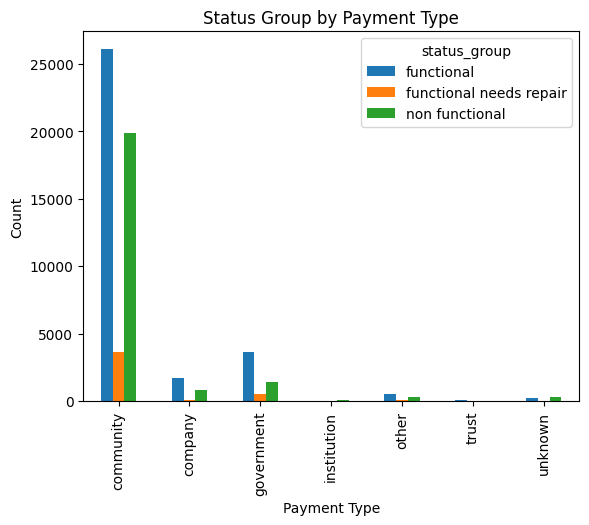

In [134]:
import matplotlib.pyplot as plt

# Assuming your dataframe is named df and contains 'payment_type' and 'status_group' columns

ct = train_df.groupby(['management_customize', 'status_group']).size().unstack(fill_value=0)

ct.plot(kind='bar')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.title('Status Group by Payment Type')
plt.show()
